In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline


print('numpy version : ',np.__version__)
print('pandas version : ',pd.__version__)
print('seaborn version : ',sns.__version__)

numpy version :  1.21.5
pandas version :  1.4.4
seaborn version :  0.11.2


## EDA

In [2]:
sns.set(rc={'figure.figsize':(20.7,8.27)})
sns.set_style("whitegrid")
sns.color_palette("dark")
plt.style.use("fivethirtyeight")

In [3]:
df = pd.read_excel('youtube_statistics.xlsx')
df

,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled,video_error_or_removed,description,No_tags,desc_len,len_title,publish_date
0,2017-11-14,Sharry Mann: Cute Munda ( Song Teaser) | Parmi...,Lokdhun Punjabi,1,12:20:39,"sharry mann|""sharry mann new song""|""sharry man...",1096327,33966,798,882,False,False,False,Presenting Sharry Mann latest Punjabi Song Cu...,15,920,81,2017-11-12
1,2017-11-14,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं...",HJ NEWS,25,05:43:56,"पीरियड्स के समय|""पेट पर पति करता ऐसा""|""देखकर द...",590101,735,904,0,True,False,False,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं...",19,2232,58,2017-11-13
2,2017-11-14,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,TFPC,24,15:48:08,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,473988,2011,243,149,False,False,False,Watch Stylish Star Allu Arjun @ ChaySam Weddin...,14,482,58,2017-11-12
3,2017-11-14,Eruma Saani | Tamil vs English,Eruma Saani,23,07:08:48,"Eruma Saani|""Tamil Comedy Videos""|""Films""|""Mov...",1242680,70353,1624,2684,False,False,False,This video showcases the difference between pe...,20,263,30,2017-11-12
4,2017-11-14,why Samantha became EMOTIONAL @ Samantha naga ...,Filmylooks,24,01:14:16,"Filmylooks|""latest news""|""telugu movies""|""telu...",464015,492,293,66,False,False,False,why Samantha became EMOTIONAL @ Samantha naga ...,11,753,88,2017-11-13
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36786,2018-06-14,फेकू आशिक़ - राजस्थान की सबसे शानदार कॉमेडी | ...,RDC Rajasthani,23,08:01:11,"twinkle vaishnav comedy|""twinkle vaishnav""|""tw...",214378,3291,404,196,False,False,False,PRG Music & RDC Rajasthani presents फेकू आशिक़...,19,818,100,2018-06-13
36787,2018-06-14,Seetha | Flowers | Ep# 364,Flowers TV,24,11:30:04,"flowers serials|""actress""|""malayalam serials""|...",406828,1726,478,1428,False,False,False,"Flowers - A R Rahman Show,Book your Tickets He...",8,468,26,2018-06-13
36788,2018-06-14,Bhramanam I Episode 87 - 12 June 2018 I Mazhav...,Mazhavil Manorama,24,05:00:02,"mazhavil manorama|""bhramanam full episode""|""gt...",386319,1216,453,697,False,False,False,Subscribe to Mazhavil Manorama now for your da...,8,2187,57,2018-06-13
36789,2018-06-14,Nua Bohu | Full Ep 285 | 13th June 2018 | Odia...,Tarang TV,24,15:07:49,"tarang|""tarang tv""|""tarang tv online""|""tarang ...",130263,698,115,65,False,False,False,Nuabohu : Story of a rustic village girl who w...,15,432,64,2018-06-13


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36791 entries, 0 to 36790
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   trending_date           36791 non-null  object        
 1   title                   36791 non-null  object        
 2   channel_title           36791 non-null  object        
 3   category_id             36791 non-null  int64         
 4   publish_time            36791 non-null  object        
 5   tags                    36791 non-null  object        
 6   views                   36791 non-null  int64         
 7   likes                   36791 non-null  int64         
 8   dislikes                36791 non-null  int64         
 9   comment_count           36791 non-null  int64         
 10  comments_disabled       36791 non-null  bool          
 11  ratings_disabled        36791 non-null  bool          
 12  video_error_or_removed  36791 non-null  bool  

Dataset terdiri dari 36.791 baris dan 18 variabel, yang mencakup:
Variabel numerik (views, likes, dislikes, comment_count, dll.), variabel kategorikal (title, channel_title, tags), variabel boolean (comments_disabled, ratings_disabled, video_error_or_removed), variabel waktu (publish_date, trending_date)


Tidak terdapat missing value kecuali pada kolom description.

In [5]:
df.describe()

,category_id,views,likes,dislikes,comment_count,No_tags,desc_len,len_title
count,36791.000000,3.679100e+04,3.679100e+04,3.679100e+04,36791.000000,36791.000000,36791.000000,36791.000000
mean,21.552173,1.071490e+06,2.745069e+04,1.685363e+03,2714.022043,18.938463,923.079123,70.609361
std,6.586716,3.207149e+06,9.783129e+04,1.619732e+04,14978.114328,9.843531,815.038867,22.409174
min,1.000000,4.024000e+03,0.000000e+00,0.000000e+00,0.000000,1.000000,3.000000,5.000000
25%,23.000000,1.256040e+05,8.790000e+02,1.090000e+02,83.000000,12.000000,368.000000,53.000000
50%,24.000000,3.078360e+05,3.126000e+03,3.310000e+02,336.000000,19.000000,677.000000,74.000000
75%,24.000000,8.066315e+05,1.409500e+04,1.032000e+03,1314.500000,25.000000,1237.000000,91.000000
max,43.000000,1.254322e+08,2.912710e+06,1.545017e+06,827755.000000,72.000000,5136.000000,100.000000


Dari hasil describe() dapat diamati bahwa:

Distribusi views, likes, dislikes, dan comment_count sangat right-skewed
Nilai maksimum jauh lebih besar dari median yang bisa jd indikasi outlier ekstrem
Rata-rata views (+-1 juta) jauh lebih tinggi dari median (+-300 ribu)
Hal ini wajar pada data YouTube karena sebagian kecil video viral mendominasi jumlah views.

In [6]:
df.describe(include=[object,bool])

,trending_date,title,channel_title,publish_time,tags,comments_disabled,ratings_disabled,video_error_or_removed,description
count,36791,36791,36791,36791,36791,36791,36791,36791,36746
unique,205,16431,1390,12375,12463,2,2,2,13979
top,2017-12-23,Mission: Impossible - Fallout (2018) - Officia...,VikatanTV,04:30:00,[none],False,False,False,Subscribers Link: http://bit.ly/2qb69dZ\n\nCon...
freq,199,19,284,333,1120,35611,36034,36780,166


## Univariate Analysis

In [7]:
numericals = df.select_dtypes(include=['int64', 'float64']).columns
numericals

Index(['category_id', 'views', 'likes', 'dislikes', 'comment_count', 'No_tags',
       'desc_len', 'len_title'],
      dtype='object')

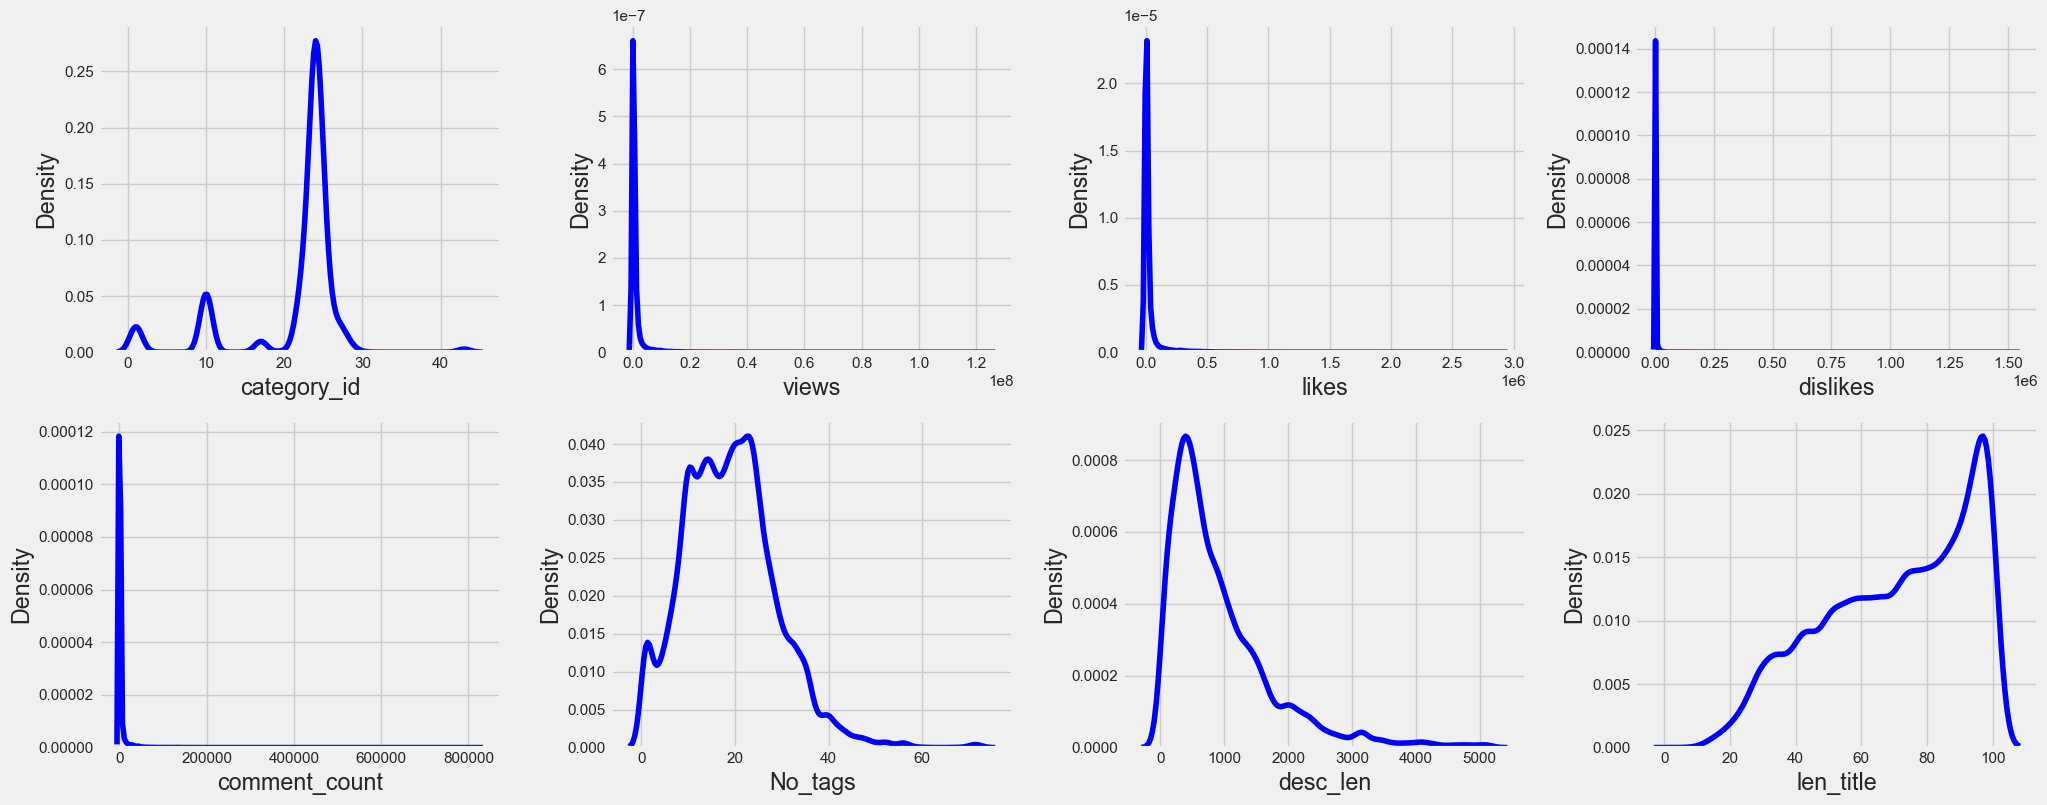

In [8]:
features = numericals 
for i in range(0, len(features)): 
    plt.subplot (2, 4, i+1) 
    sns.kdeplot(x=df[features[i]], color='blue') 
    plt.xlabel(features[i])
    plt.tight_layout()

Berdasarkan visualisasi univariat menggunakan histogram, dapat dilihat bahwa variabel views, likes, dislikes, dan comment_count memiliki pola sebaran yang tidak simetris (right-skewed) bentuk yang tipis ekstrim seperti ini juga bisa menjadi indikasi bahwa sebaran dari outlier begitu besar sehingga harus diatasi apabila memang demikian.

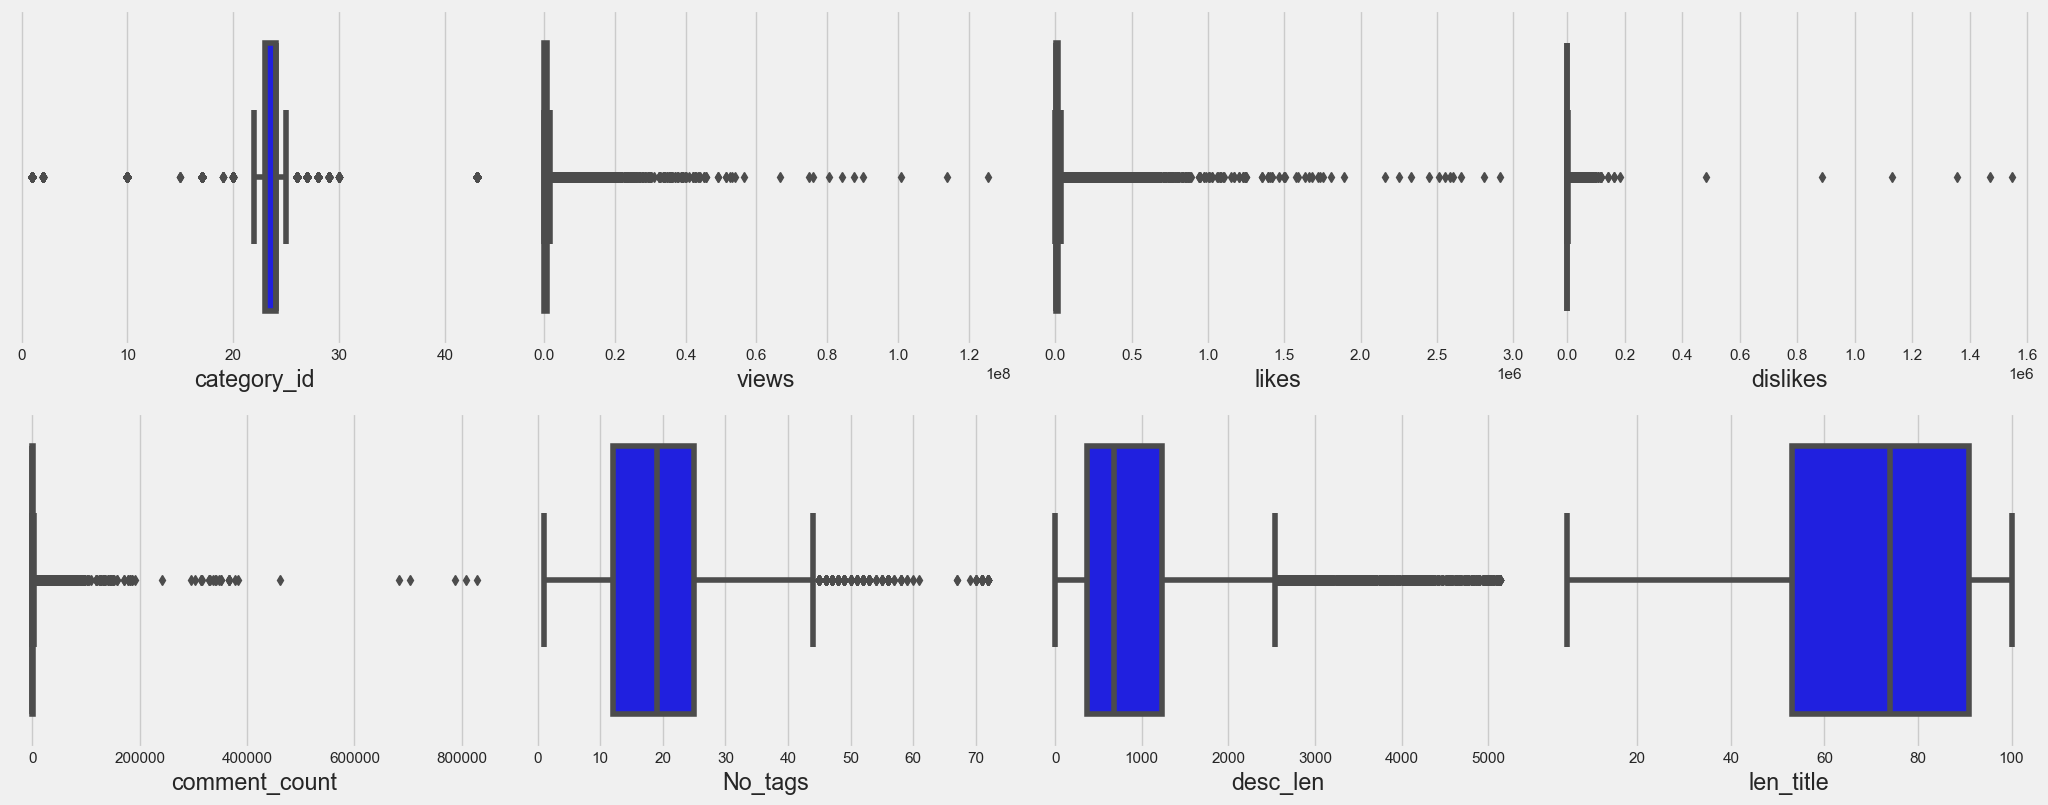

In [9]:
features = numericals 
for i in range(0, len(features)): 
    plt.subplot (2, 4, i+1) 
    sns.boxplot(x=df[features[i]], color='blue') 
    plt.xlabel(features[i])
    plt.tight_layout()

Sesuai dengan histogram, boxplot multivariat menunjukkan bahwa sebagian besar variabel numerik memiliki banyak outlier, terutama pada views, likes, dislikes, dan comment_count. Hal ini wajar mengingat karakteristik data media sosial yang bersifat viral, di mana hanya sebagian kecil video yang memiliki nilai ekstrem sangat tinggi. Untuk mengurangi pengaruh outlier terhadap model, dilakukan proses capping menggunakan metode IQR.

In [10]:
df["trending_date"] = pd.to_datetime(df["trending_date"], format="%Y-%m-%d")

In [11]:
trending_counts = (
    df.groupby("trending_date")
      .size()
      .reset_index(name="count")
)

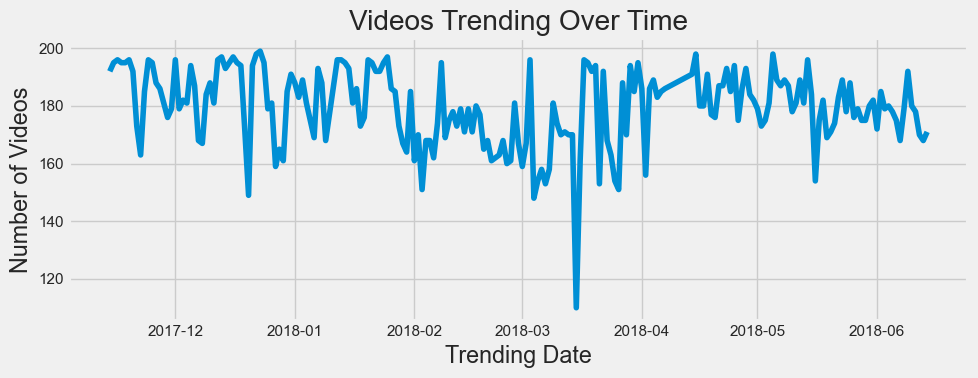

In [12]:
plt.figure(figsize=(10,4))
plt.plot(trending_counts["trending_date"], trending_counts["count"])
plt.xlabel("Trending Date")
plt.ylabel("Number of Videos")
plt.title("Videos Trending Over Time")
plt.tight_layout()

Grafik jumlah video yang masuk trending berdasarkan tanggal menunjukkan bahwa jumlah video trending relatif stabil dari waktu ke waktu, dengan fluktuasi harian yang tidak terlalu ekstrem. Namun terdapat beberapa penurunan tajam pada periode tertentu, yang kemungkinan disebabkan oleh faktor eksternal yang tidk dapat disimpulkan saat ini

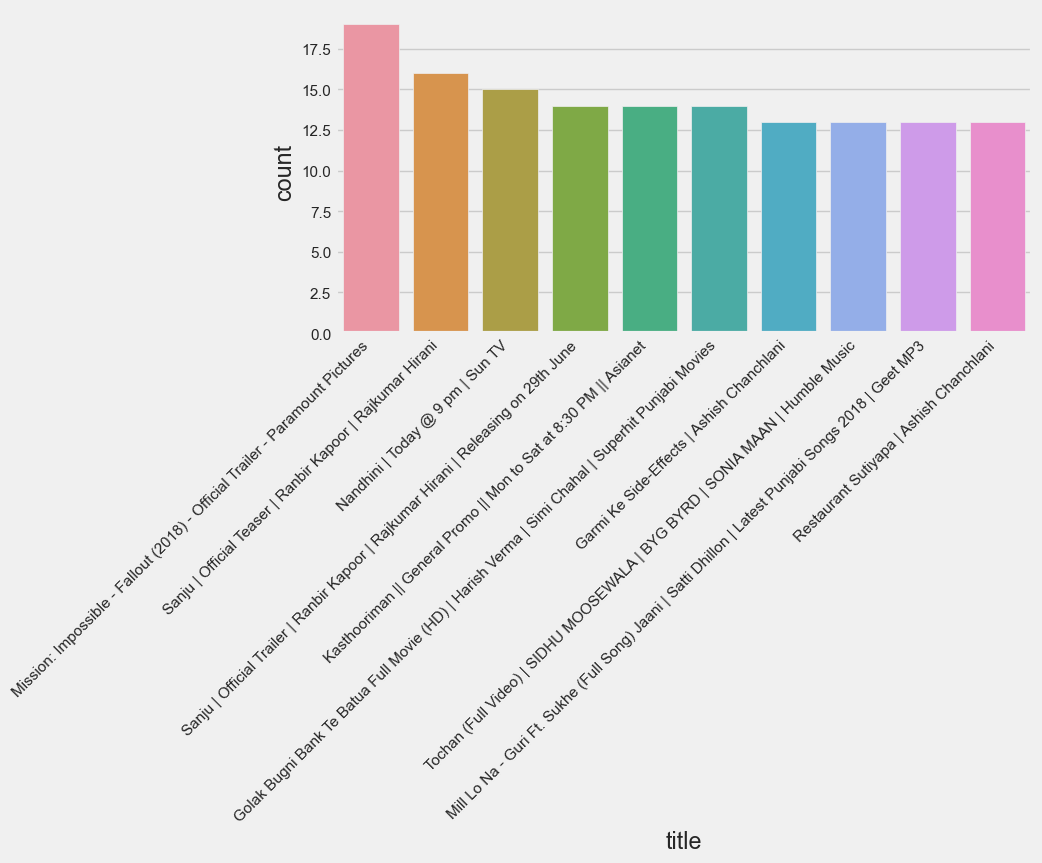

In [13]:
top_titles = df["title"].value_counts().nlargest(10).index

plt.figure(figsize=(8,4))
sns.countplot(x="title", data=df[df["title"].isin(top_titles)], order=top_titles)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

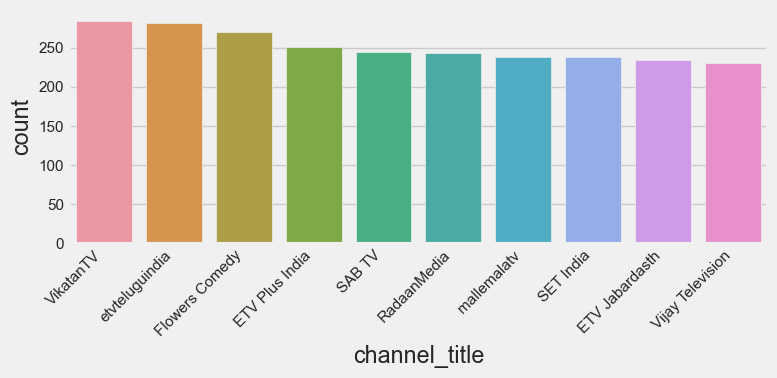

In [14]:
top_channels = df["channel_title"].value_counts().nlargest(10).index

plt.figure(figsize=(8,4))
sns.countplot(x="channel_title", data=df[df["channel_title"].isin(top_channels)], order=top_channels)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

Top 1 title video viral di youtube adalah Nandhini | Today  @ 9 AM | Sun TV dan top 1 channel title adalah Vikatan TV.

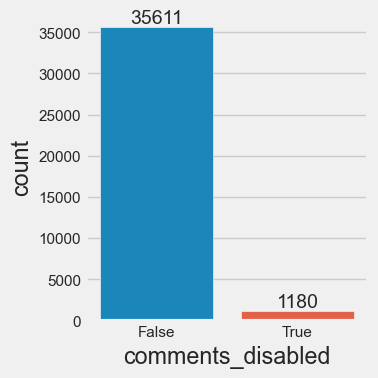

In [15]:
plt.figure(figsize=(4,4))
ax = sns.countplot(x="comments_disabled", data=df)
ax.bar_label(ax.containers[0], fmt='%.0f') 
plt.tight_layout()

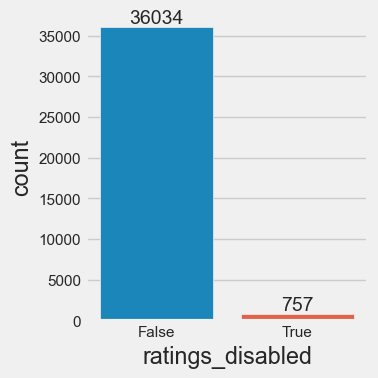

In [16]:
plt.figure(figsize=(4,4))
ax = sns.countplot(x="ratings_disabled", data=df)
ax.bar_label(ax.containers[0], fmt='%.0f') 
plt.tight_layout()

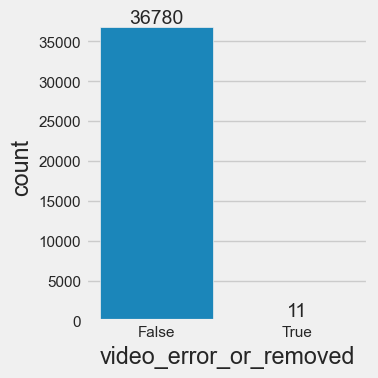

In [17]:
plt.figure(figsize=(4,4))
ax = sns.countplot(x="video_error_or_removed", data=df)
ax.bar_label(ax.containers[0], fmt='%.0f') 
plt.tight_layout()

Sebagian besar dari video viral memiliki fitur komentar dan rating yang dinyalakan dan hanya 11 dari keseluruhan data yang memiliki kendala video error ataupun removed (kurang dari 1%).

## Multivariate Analysis

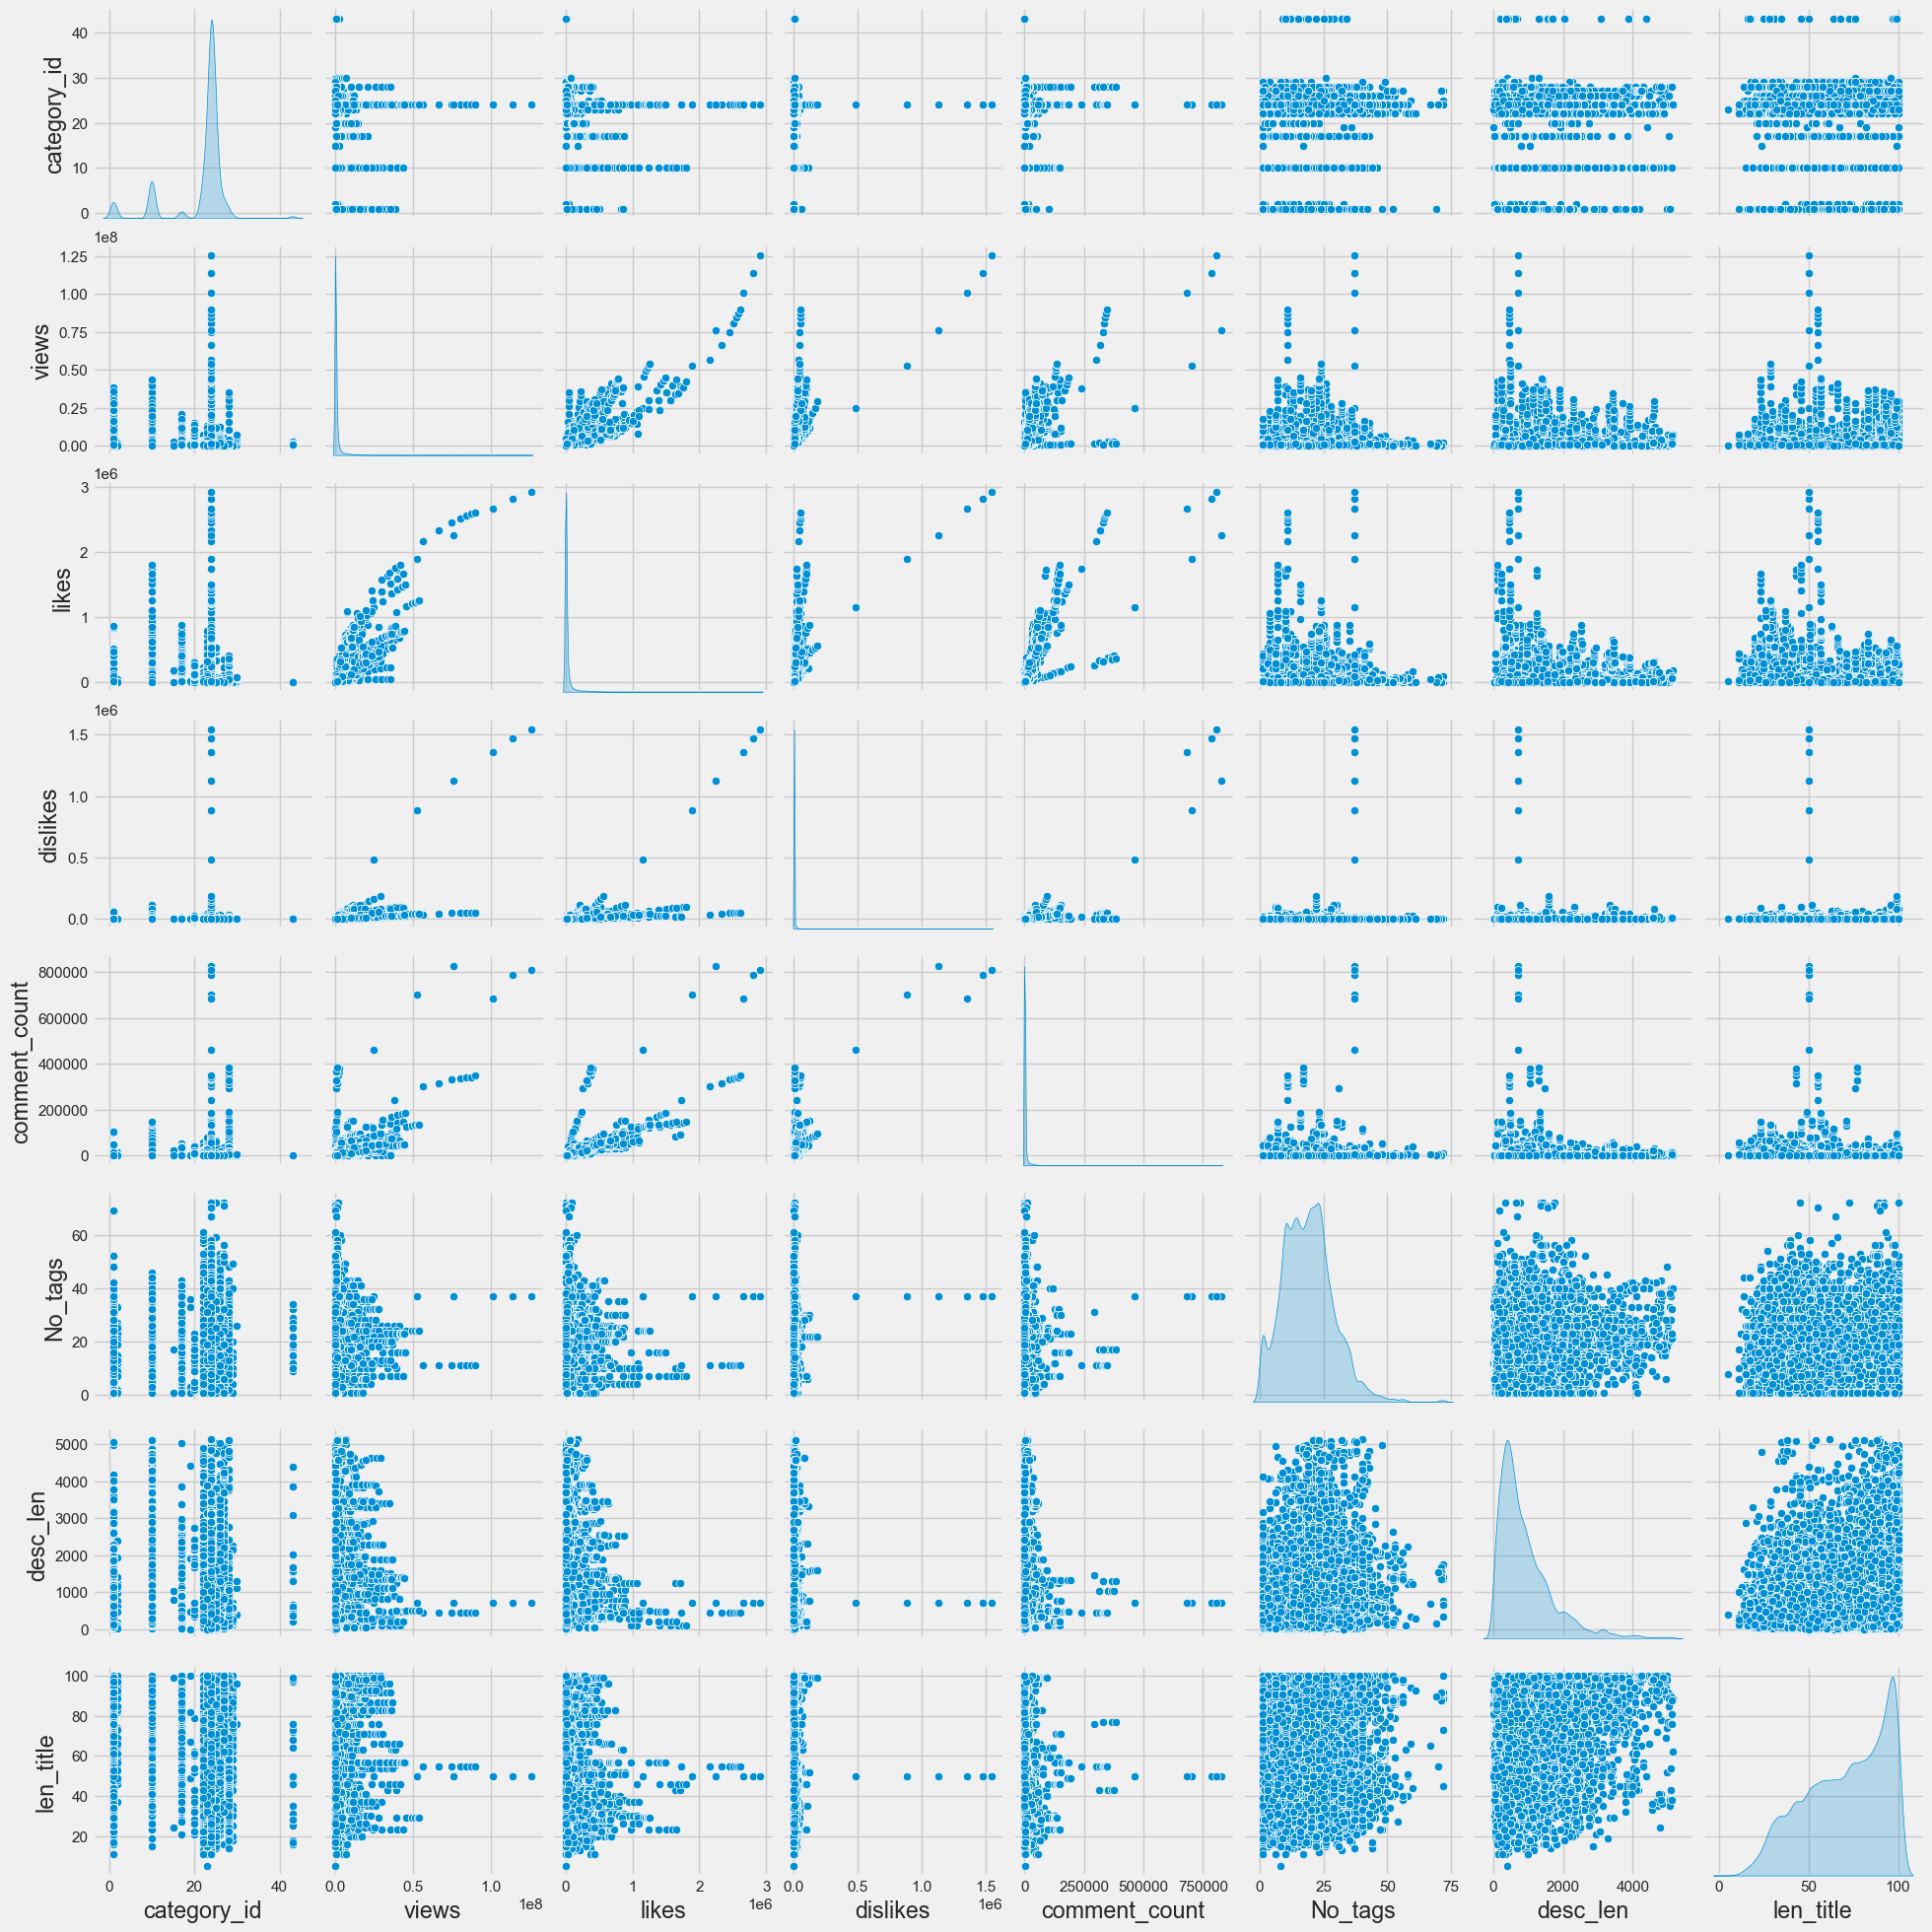

In [18]:
sns.pairplot(df.select_dtypes(include=['int64','float64']), diag_kind='kde')

Berdasarkan visualisasi multivariate menggunakan pairplot, dapat dilihat bahwa variabel views, likes, dislikes, dan comment_count memiliki pola sebaran yang tidak simetris (right-skewed) serta menunjukkan hubungan yang cenderung linear satu sama lain. Hal ini mengindikasikan bahwa video dengan jumlah views tinggi umumnya juga memiliki likes, dislikes, dan komentar yang tinggi. Pola ini memperkuat dugaan bahwa engagement pengguna sangat berkaitan erat dengan jumlah views.

<AxesSubplot:>

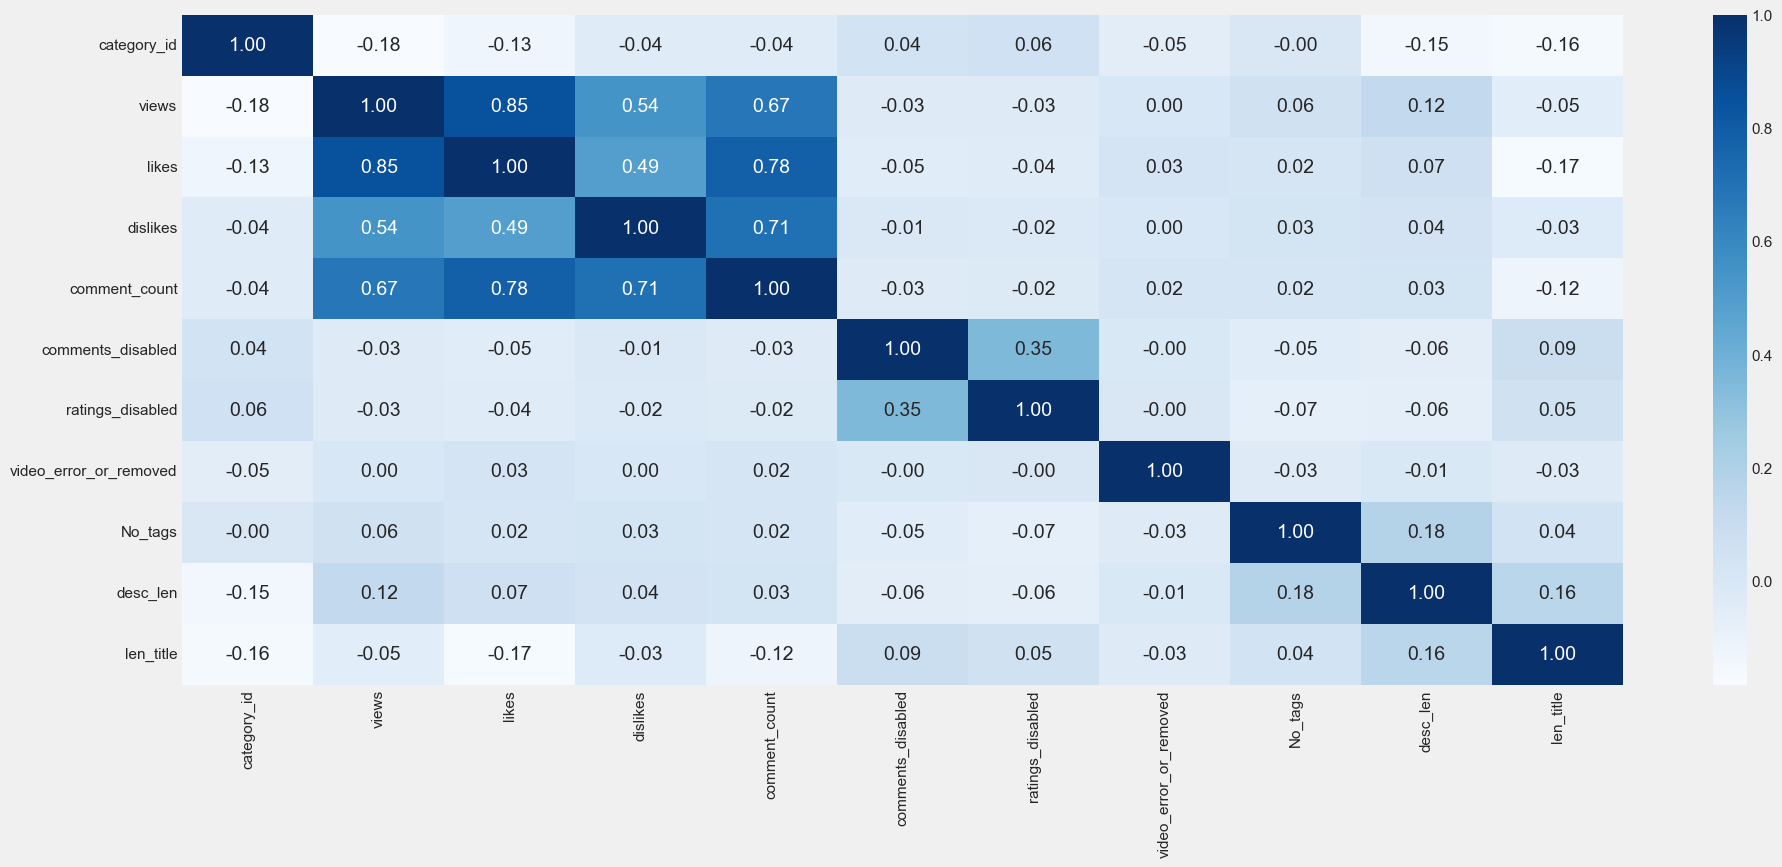

In [19]:
sns.heatmap(df.corr(),cmap='Blues',annot=True, fmt=".2f")

In [20]:
df.corr()

,category_id,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled,video_error_or_removed,No_tags,desc_len,len_title
category_id,1.000000,-0.183014,-0.127137,-0.042272,-0.035696,0.039006,0.058516,-0.053962,-0.000233,-0.148119,-0.163273
views,-0.183014,1.000000,0.850073,0.543310,0.674151,-0.034498,-0.034408,0.004920,0.055327,0.122142,-0.051559
likes,-0.127137,0.850073,1.000000,0.494518,0.780445,-0.045795,-0.040670,0.028414,0.019600,0.065086,-0.170257
dislikes,-0.042272,0.543310,0.494518,1.000000,0.708100,-0.011829,-0.015082,0.002964,0.033725,0.035031,-0.030300
comment_count,-0.035696,0.674151,0.780445,0.708100,1.000000,-0.032985,-0.024135,0.015732,0.020227,0.031604,-0.119092
comments_disabled,0.039006,-0.034498,-0.045795,-0.011829,-0.032985,1.000000,0.348523,-0.003148,-0.047492,-0.056063,0.088646
ratings_disabled,0.058516,-0.034408,-0.040670,-0.015082,-0.024135,0.348523,1.000000,-0.002507,-0.071181,-0.063888,0.052152
video_error_or_removed,-0.053962,0.004920,0.028414,0.002964,0.015732,-0.003148,-0.002507,1.000000,-0.031516,-0.006091,-0.032883
No_tags,-0.000233,0.055327,0.019600,0.033725,0.020227,-0.047492,-0.071181,-0.031516,1.000000,0.177760,0.041871
desc_len,-0.148119,0.122142,0.065086,0.035031,0.031604,-0.056063,-0.063888,-0.006091,0.177760,1.000000,0.159658


## Data Preprocessing

In [21]:
df.duplicated().sum()

4229

In [22]:
df = df.drop_duplicates()

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 32562 entries, 0 to 36769
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   trending_date           32562 non-null  datetime64[ns]
 1   title                   32562 non-null  object        
 2   channel_title           32562 non-null  object        
 3   category_id             32562 non-null  int64         
 4   publish_time            32562 non-null  object        
 5   tags                    32562 non-null  object        
 6   views                   32562 non-null  int64         
 7   likes                   32562 non-null  int64         
 8   dislikes                32562 non-null  int64         
 9   comment_count           32562 non-null  int64         
 10  comments_disabled       32562 non-null  bool          
 11  ratings_disabled        32562 non-null  bool          
 12  video_error_or_removed  32562 non-null  bool  

In [24]:
from scipy.stats import zscore
import numpy as np

z_scores = np.abs(zscore(df[numericals], nan_policy='omit'))

In [25]:
outliers_before = pd.Series(
    (z_scores > 3).sum(axis=0),
    index=numericals,
    name='outliers_before'
)

outliers_before

category_id      1670
views             463
likes             535
dislikes           66
comment_count     234
No_tags           255
desc_len          673
len_title           0
Name: outliers_before, dtype: int64

In [26]:
before_counts = df[numericals].count()
before_counts

category_id      32562
views            32562
likes            32562
dislikes         32562
comment_count    32562
No_tags          32562
desc_len         32562
len_title        32562
dtype: int64

In [27]:
def get_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    mask = (df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)
    return df.loc[mask, col]

## Pengecekan Ulang Cleaned Data dg EDA

In [28]:
numericals = df.select_dtypes(include=['int64', 'float64']) \
               .drop(columns=['category_id']) \
               .columns

In [29]:
for col in numericals:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    mincap = Q1 - 1.5 * IQR
    maxcap = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower=mincap, upper=maxcap)

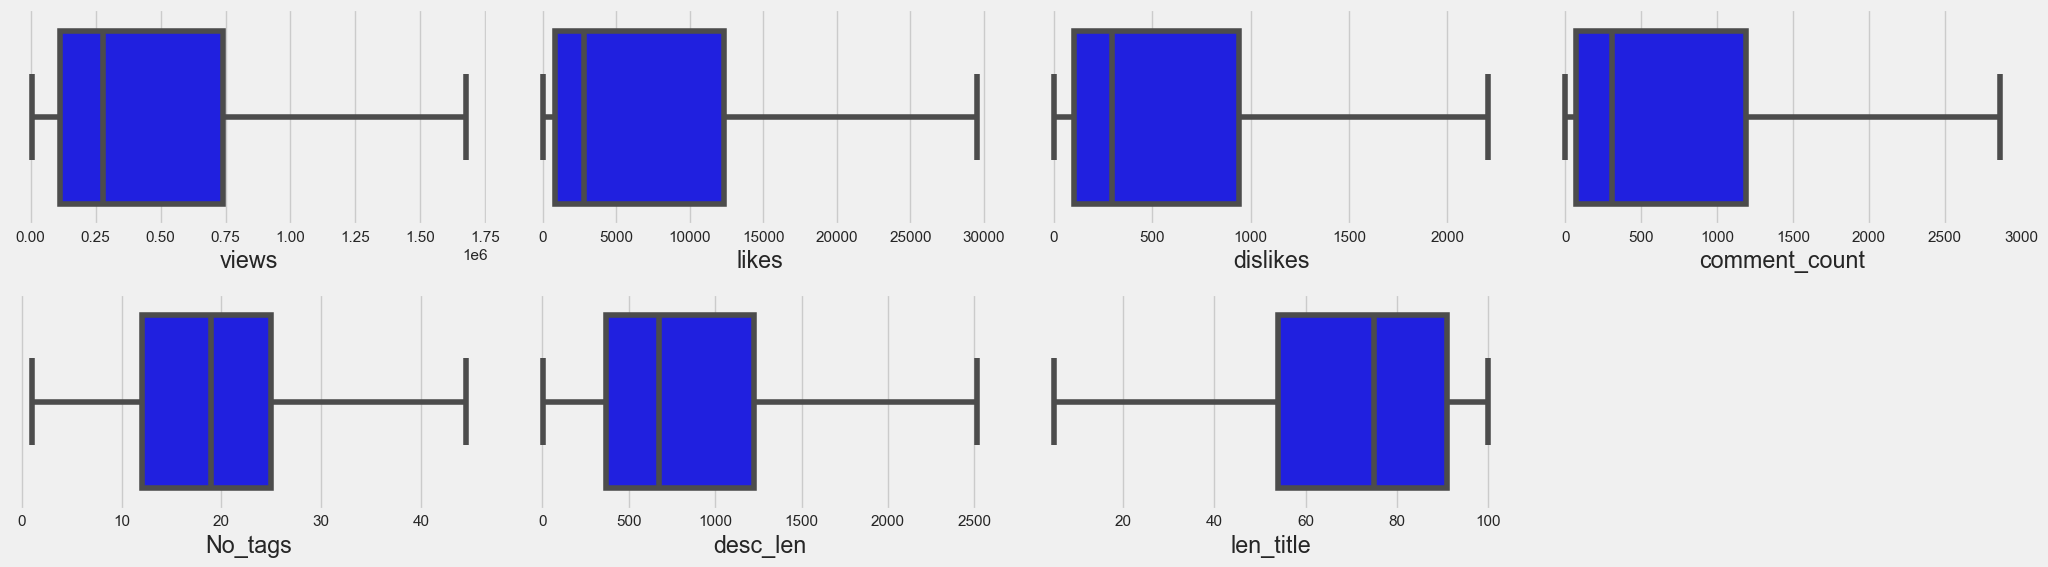

In [30]:
features = numericals 
for i in range(0, len(features)): 
    plt.subplot (3, 4, i+1) 
    sns.boxplot(x=df[features[i]], color='blue') 
    plt.xlabel(features[i])
    plt.tight_layout()

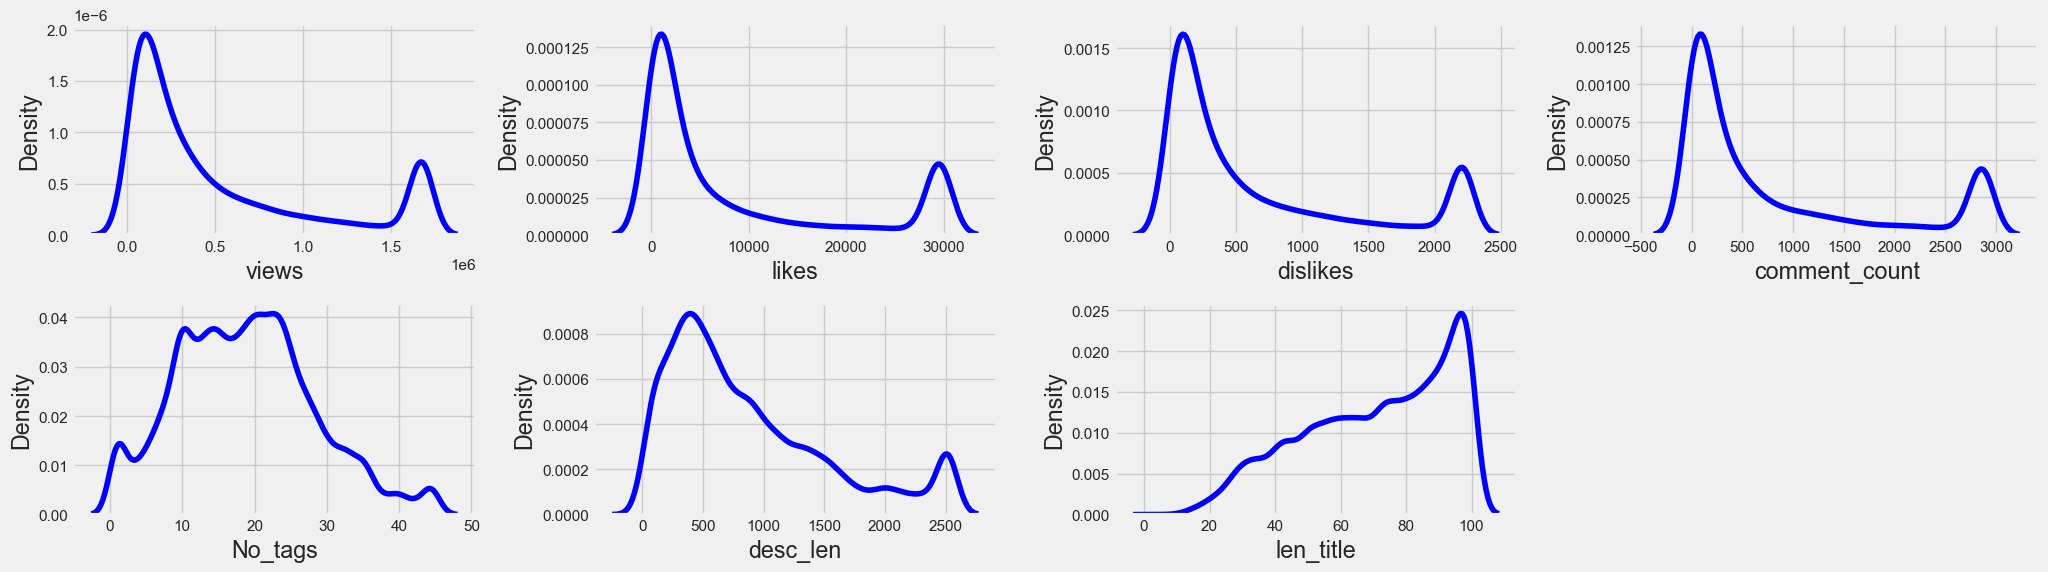

In [31]:
features = numericals 
for i in range(0, len(features)): 
    plt.subplot (3, 4, i+1) 
    sns.kdeplot(x=df[features[i]], color='blue') 
    plt.xlabel(features[i])
    plt.tight_layout()

Sesudah data cleaning dapat dilohat bahwa tidak terdapat lagi extreme outliers dan siap digunakan untuk analisis, meskipun masih terdapat pola skewness yang mirip seperti semula . Akan tetapi muncul puncak-puncak kecil, terutama di ujung data, hal ini normal dikarenakan Outliers dihandle dengan cara dimasukkan sebagai nilai maximal/minimal dari IQR, yang membuat adanya lonjakan jumlah data pada titik-titik tersebut.

<AxesSubplot:>

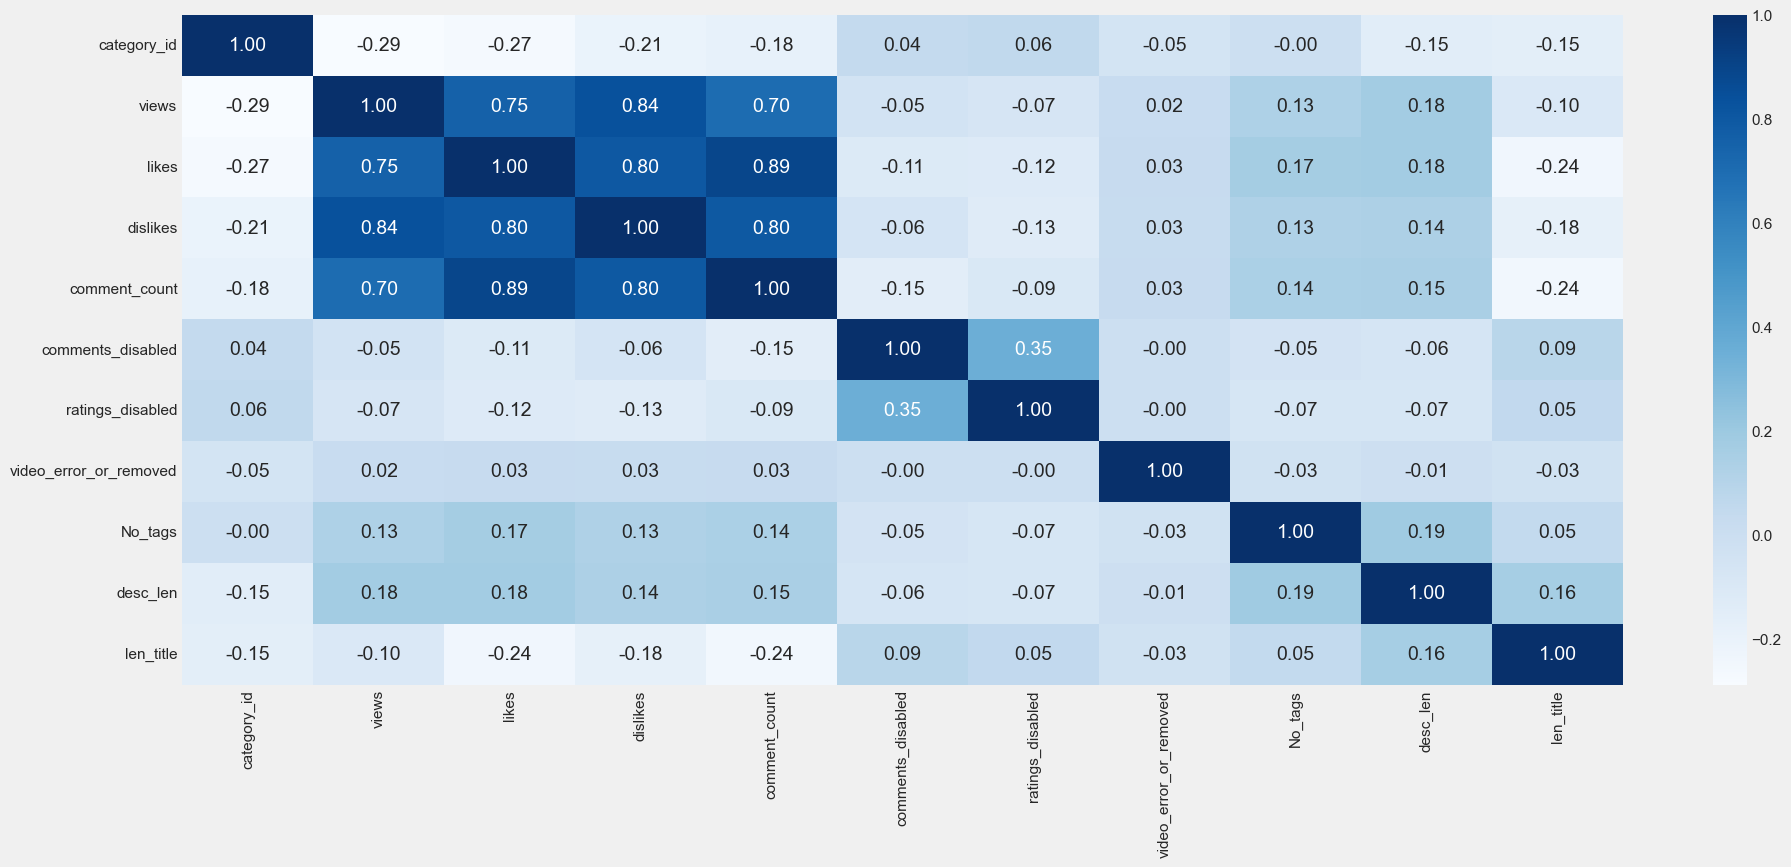

In [32]:
sns.heatmap(df.corr(),cmap='Blues',annot=True, fmt=".2f")

In [33]:
df.corr()

,category_id,views,likes,dislikes,comment_count,comments_disabled,ratings_disabled,video_error_or_removed,No_tags,desc_len,len_title
category_id,1.000000,-0.287254,-0.266485,-0.205018,-0.182345,0.040086,0.058600,-0.052498,-0.003784,-0.145832,-0.153855
views,-0.287254,1.000000,0.753800,0.835370,0.701101,-0.045740,-0.066751,0.024433,0.132663,0.178257,-0.099513
likes,-0.266485,0.753800,1.000000,0.800798,0.892261,-0.113393,-0.116375,0.030409,0.165495,0.177320,-0.237619
dislikes,-0.205018,0.835370,0.800798,1.000000,0.798491,-0.056640,-0.128154,0.028939,0.128684,0.135659,-0.176056
comment_count,-0.182345,0.701101,0.892261,0.798491,1.000000,-0.149761,-0.094534,0.034549,0.144553,0.148141,-0.243621
comments_disabled,0.040086,-0.045740,-0.113393,-0.056640,-0.149761,1.000000,0.353362,-0.003086,-0.047820,-0.061413,0.088597
ratings_disabled,0.058600,-0.066751,-0.116375,-0.128154,-0.094534,0.353362,1.000000,-0.002445,-0.074696,-0.071120,0.050676
video_error_or_removed,-0.052498,0.024433,0.030409,0.028939,0.034549,-0.003086,-0.002445,1.000000,-0.031055,-0.005806,-0.032087
No_tags,-0.003784,0.132663,0.165495,0.128684,0.144553,-0.047820,-0.074696,-0.031055,1.000000,0.186777,0.046422
desc_len,-0.145832,0.178257,0.177320,0.135659,0.148141,-0.061413,-0.071120,-0.005806,0.186777,1.000000,0.163510


dapat dilihat bahwa Dislikes, Likes, and Jumlah Komen memiliki korelasi Tinggi-Sangat Tinggi, terutama dislikes dengan kategori sangat tinggi (0.84) terhadap views. akan tetapi dari ketiga variabel itu juga memiliki korelasi yang cukup tinggi dengan satu sama lain. terutama likes dan dislikes yg memiliki nilai 0.89. Hal ini bisa menjadi indikasi awal dari multikolinearitas, dan apabila terdapat problem pada model harus diatasi dengan mehapus salah satu variabel ataupun menggunakan metode prediksi yang robust terhadap problem ini.

Variabeel lain tidak menunjukkan korelasi yang begitu mencolok terhadap views, kecuali category id dengan korelasi negatif 0,29 (lemah)

## Uji T untuk Cek Korelasi antara data boolean & Views

In [34]:
from scipy.stats import ttest_ind

group1 = df[df["ratings_disabled"] == 0]["views"]
group2 = df[df["ratings_disabled"] == 1]["views"]

t_stat, p_value = ttest_ind(group1, group2, equal_var=False)
t_stat, p_value

(18.196660639997905, 1.0836219865397422e-61)

In [35]:
from scipy.stats import ttest_ind

group1 = df[df["comments_disabled"] == 0]["views"]
group2 = df[df["comments_disabled"] == 1]["views"]

t_stat, p_value = ttest_ind(group1, group2, equal_var=False)
t_stat, p_value

(9.961768593111792, 1.6374373184442481e-22)

In [36]:
from scipy.stats import ttest_ind

group1 = df[df["video_error_or_removed"] == 0]["views"]
group2 = df[df["video_error_or_removed"] == 1]["views"]

t_stat, p_value = ttest_ind(group1, group2, equal_var=False)
t_stat, p_value

(-4.240084155816904, 0.002833865102848214)

Berdasarkan uji ANOVA, kategori video memiliki pengaruh signifikan terhadap jumlah views (p < 0,05). Selain itu, hasil uji t menunjukkan bahwa status komentar, rating, serta error video berhubungan signifikan dengan perbedaan rata-rata views.

## Feature Encoding, Selection, & Extraction

In [37]:
# Ngasih label 0,1
from sklearn.preprocessing import LabelEncoder
df['disabled_comms'] = LabelEncoder().fit_transform(df['comments_disabled'])
df['disabled_ratings'] = LabelEncoder().fit_transform(df['ratings_disabled'])
df['error'] = LabelEncoder().fit_transform(df['video_error_or_removed'])
df.head()

,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,...,ratings_disabled,video_error_or_removed,description,No_tags,desc_len,len_title,publish_date,disabled_comms,disabled_ratings,error
0,2017-11-14,Sharry Mann: Cute Munda ( Song Teaser) | Parmi...,Lokdhun Punjabi,1,12:20:39,"sharry mann|""sharry mann new song""|""sharry man...",1096327.0,29547.5,798.0,882.0,...,False,False,Presenting Sharry Mann latest Punjabi Song Cu...,15.0,920.0,81,2017-11-12,0,0,0
1,2017-11-14,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं...",HJ NEWS,25,05:43:56,"पीरियड्स के समय|""पेट पर पति करता ऐसा""|""देखकर द...",590101.0,735.0,904.0,0.0,...,False,False,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं...",19.0,2232.0,58,2017-11-13,1,0,0
2,2017-11-14,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,TFPC,24,15:48:08,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,473988.0,2011.0,243.0,149.0,...,False,False,Watch Stylish Star Allu Arjun @ ChaySam Weddin...,14.0,482.0,58,2017-11-12,0,0,0
3,2017-11-14,Eruma Saani | Tamil vs English,Eruma Saani,23,07:08:48,"Eruma Saani|""Tamil Comedy Videos""|""Films""|""Mov...",1242680.0,29547.5,1624.0,2684.0,...,False,False,This video showcases the difference between pe...,20.0,263.0,30,2017-11-12,0,0,0
4,2017-11-14,why Samantha became EMOTIONAL @ Samantha naga ...,Filmylooks,24,01:14:16,"Filmylooks|""latest news""|""telugu movies""|""telu...",464015.0,492.0,293.0,66.0,...,False,False,why Samantha became EMOTIONAL @ Samantha naga ...,11.0,753.0,88,2017-11-13,0,0,0


In [38]:
df["publish_hour"] = pd.to_datetime(df["publish_time"], format="%H:%M:%S").dt.hour

In [39]:
df["publish_date"] = pd.to_datetime(df["publish_date"])
df["is_weekend"] = df["publish_date"].dt.weekday.isin([5, 6]).astype('int64')

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 32562 entries, 0 to 36769
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   trending_date           32562 non-null  datetime64[ns]
 1   title                   32562 non-null  object        
 2   channel_title           32562 non-null  object        
 3   category_id             32562 non-null  int64         
 4   publish_time            32562 non-null  object        
 5   tags                    32562 non-null  object        
 6   views                   32562 non-null  float64       
 7   likes                   32562 non-null  float64       
 8   dislikes                32562 non-null  float64       
 9   comment_count           32562 non-null  float64       
 10  comments_disabled       32562 non-null  bool          
 11  ratings_disabled        32562 non-null  bool          
 12  video_error_or_removed  32562 non-null  bool  

Feature Selection for Ridge Regression |
untuk model awal akan pakai semua kecuali : 

- title -> diwakilkan len title
- description -> diwakilkan desc title
- publish time -> diwakilkan publish date hour and minute.

tidak melakukan feature engineering tambahan untuk saat ini.

## Model & Hypertuning

In [41]:
X = df.select_dtypes(include=["int64", "float64"])
X = X.drop(['views'],axis=1)
X

,category_id,likes,dislikes,comment_count,No_tags,desc_len,len_title,disabled_comms,disabled_ratings,error,publish_hour,is_weekend
0,1,29547.5,798.0,882.0,15.0,920.0,81,0,0,0,12,1
1,25,735.0,904.0,0.0,19.0,2232.0,58,1,0,0,5,0
2,24,2011.0,243.0,149.0,14.0,482.0,58,0,0,0,15,1
3,23,29547.5,1624.0,2684.0,20.0,263.0,30,0,0,0,7,1
4,24,492.0,293.0,66.0,11.0,753.0,88,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
36739,24,29547.5,2209.0,2859.0,37.0,1398.0,72,0,0,0,13,0
36740,17,13316.0,552.0,1175.0,31.0,320.0,87,0,0,0,3,0
36741,1,29547.5,2209.0,2859.0,18.0,1491.0,76,0,0,0,6,0
36758,23,29547.5,2209.0,2859.0,13.0,441.0,32,0,0,0,8,0


In [42]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 32562 entries, 0 to 36769
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   category_id       32562 non-null  int64  
 1   likes             32562 non-null  float64
 2   dislikes          32562 non-null  float64
 3   comment_count     32562 non-null  float64
 4   No_tags           32562 non-null  float64
 5   desc_len          32562 non-null  float64
 6   len_title         32562 non-null  int64  
 7   disabled_comms    32562 non-null  int64  
 8   disabled_ratings  32562 non-null  int64  
 9   error             32562 non-null  int64  
 10  publish_hour      32562 non-null  int64  
 11  is_weekend        32562 non-null  int64  
dtypes: float64(5), int64(7)
memory usage: 4.2 MB


In [43]:
y = df["views"]
y

0        1096327.000
1         590101.000
2         473988.000
3        1242680.000
4         464015.000
            ...     
36739    1676067.875
36740     770873.000
36741    1676067.875
36758    1214423.000
36769     132055.000
Name: views, Length: 32562, dtype: float64

In [44]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [46]:
#Standardize

from sklearn.preprocessing import StandardScaler

cols = ['likes','dislikes','comment_count','No_tags','desc_len','len_title']

scaler = StandardScaler()

X_train[cols] = scaler.fit_transform(X_train[cols])
X_test[cols]  = scaler.transform(X_test[cols])

In [47]:
regressor = LinearRegression()
regressor.fit(X_train, y_train)
y_pred = regressor.predict(X_test)

In [48]:
# Evaluation metrics
print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))
print("R2  :", r2_score(y_test, y_pred))

MAE : 190762.5714579409
RMSE: 280436.2343034618
R2  : 0.7348952383766072


In [49]:
# coba buat new x dengan comment count dropped (korelasi 0.89 terhadap likes) untuk dimodelkan
# Drop comment_count
x_no_comment = X.drop(columns=["comment_count"])
x_no_comment

,category_id,likes,dislikes,No_tags,desc_len,len_title,disabled_comms,disabled_ratings,error,publish_hour,is_weekend
0,1,29547.5,798.0,15.0,920.0,81,0,0,0,12,1
1,25,735.0,904.0,19.0,2232.0,58,1,0,0,5,0
2,24,2011.0,243.0,14.0,482.0,58,0,0,0,15,1
3,23,29547.5,1624.0,20.0,263.0,30,0,0,0,7,1
4,24,492.0,293.0,11.0,753.0,88,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
36739,24,29547.5,2209.0,37.0,1398.0,72,0,0,0,13,0
36740,17,13316.0,552.0,31.0,320.0,87,0,0,0,3,0
36741,1,29547.5,2209.0,18.0,1491.0,76,0,0,0,6,0
36758,23,29547.5,2209.0,13.0,441.0,32,0,0,0,8,0


In [50]:
x_train, x_test, y_train, y_test = train_test_split(x_no_comment, y, test_size=1/3, random_state=42)

In [51]:
regressor = LinearRegression()
regressor.fit(x_train, y_train)
y_pred = regressor.predict(x_test)

print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))
print("R2  :", r2_score(y_test, y_pred))

MAE : 191733.11371543008
RMSE: 281745.3962073803
R2  : 0.7330012322725477


Dengan membandingkan R^2 dan RMSE dari model linear dengan comment count dan tanpa, dapat disimpulkan bahwa keberadaan comment count meningkatkan nilai metrik evaluasi terhadap model. Oleh karena itu sebagai perbandingan dilakukan kembali pemodelan untuk X lengkap (dengan comment count) dengan metode regresi yakni ridge, lasso, dan elasticnet untuk mencari model dengan R^2 sebelum dilakukan hyperparameter tuning.

In [52]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [53]:
model = Ridge()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))
print("R2  :", r2_score(y_test, y_pred))

MAE : 190751.5132123179
RMSE: 280422.4272833679
R2  : 0.7349213421122667


In [54]:
model = Lasso()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))
print("R2  :", r2_score(y_test, y_pred))

MAE : 190760.86711989218
RMSE: 280433.94298832444
R2  : 0.7348995704563988


In [55]:
model = ElasticNet()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("MAE :", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred, squared=False))
print("R2  :", r2_score(y_test, y_pred))

MAE : 191543.28574571913
RMSE: 281221.14955599344
R2  : 0.7334091538375553


Setelah membandingkan model-model tersebut, model dengan R^2 paling tinggi dan RMSE paling rendah adalah model ridge dengan RMSE 280422.427 dan R^2 73.492. Oleh karena itu dilakukan Hyperparameter tuning untuk mencari parameter terbaik untuk model ridge.

In [56]:
pipe = Pipeline([("scaler", StandardScaler()), ("ridge", Ridge())])
param_grid = {"ridge__alpha": np.logspace(-4, 4, 20)}
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('ridge', Ridge())]),
             n_jobs=-1,
             param_grid={'ridge__alpha': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04])},
             scoring='r2')

In [57]:
print(grid.best_params_)
print(grid.best_score_)

{'ridge__alpha': 4.281332398719396}
0.7348846012795406


Setelah dilakukan GridSearchCV untuk parameter alpha dengan skema 5-fold cross-validation dan coring menggunakan R² didapatkan 
Hasil:


Alpha terbaik ≈ 4.28

In [58]:
best_model = grid.best_estimator_

r2_test = best_model.score(X_test, y_test)
y_pred = best_model.predict(X_test)
rmse = mean_squared_error(y_test, y_pred, squared=False)
print(f"R^2  : {r2_test}")
print(f"RMSE : {rmse}")

R^2  : 0.7349003104382962
RMSE : 280433.5515966802


Dengan paramter terbaik didapatkan model stabil dengan R^2 sebesar 73.49% dan RMSE 280433.55.

In [59]:
best_model = grid.best_estimator_

coef = best_model.named_steps["ridge"].coef_
intercept = best_model.named_steps["ridge"].intercept_

coef_table = pd.DataFrame({
    "feature": X.columns,
    "beta": coef
}).sort_values(by="beta", key=abs, ascending=False)

coef_table

,feature,beta
2,dislikes,365820.039570
1,likes,164304.530840
3,comment_count,-63655.013300
0,category_id,-44275.572394
8,disabled_ratings,29276.938432
6,len_title,24409.548652
5,desc_len,17963.863280
10,publish_hour,7913.432885
4,No_tags,4125.110161
11,is_weekend,-3896.075874
